In [ ]:
import pandas as pd
from tqdm import tqdm

import seaborn as sns
import matplotlib.pyplot as plt

from pygments.lexers import JsonLexer

from google_play_scraper import Sort, reviews, app

%matplotlib inline
%config InlineBackend.figure_format='retina'

sns.set(style='whitegrid', palette='muted', font_scale=1.2)

In [ ]:
apps_ids = [
    'br.com.brainweb.ifood', 'com.cerveceriamodelo.modelonow', 'com.mcdo.mcdonalds',
    'habibs.alphacode.com.br', 'com.ubercab.eats', 'com.grability.rappi',
    'burgerking.com.br.appandroid', 'com.vanuatu.aiqfome'
]


In [ ]:
app_infos = []

for ap in tqdm(apps_ids):
    info = app(ap, lang='en', country='us')
    del info['comments']
    app_infos.append(info)


In [19]:
app_infos_df = pd.DataFrame(app_infos)
app_infos_df.head(2)

,title,description,descriptionHTML,summary,installs,minInstalls,realInstalls,score,ratings,reviews,...,contentRating,contentRatingDescription,adSupported,containsAds,released,lastUpdatedOn,updated,version,appId,url
0,iFood comida e mercado em casa,"Buy in markets, restaurants, pharmacies and pe...","Buy in markets, restaurants, pharmacies and pe...","Order food delivery, market, drinks, pharmacy ...","100,000,000+",100000000,137906601,4.516206,13358385,2745,...,Everyone,None,False,False,"Apr 25, 2012","Oct 27, 2025",1.761600e+09,10.94.0,br.com.brainweb.ifood,https://play.google.com/store/apps/details?id=...
1,Zé Delivery,"With Zé Delivery, your drinks arrive in minute...","With Zé Delivery, your drinks arrive in minute...","Buy beer, wine, whiskey, spirits and more with...","10,000,000+",10000000,29708211,4.828767,1534203,317,...,Mature 17+,Use of Alcohol,False,False,"Aug 19, 2016","Oct 20, 2025",1.760994e+09,25.42.1,com.cerveceriamodelo.modelonow,https://play.google.com/store/apps/details?id=...


In [ ]:
app_reviews = []

for ap in tqdm(apps_ids):
    for score in list(range(1, 6)):
        for sort_order in [Sort.MOST_RELEVANT, Sort.NEWEST]:
            rvs, _ = reviews(
                ap,
                lang='pt',
                country='br',
                sort=sort_order,
                count=400 if score == 3 else 200,
                filter_score_with=score
            )
            for r in rvs:
                r['sortOrder'] = 'most_relevant' if sort_order == Sort.MOST_RELEVANT else 'newest'
                r['appId'] = ap
            app_reviews.extend(rvs)


In [21]:
app_reviews_df = pd.DataFrame(app_reviews)
app_reviews_df.head(2)

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,sortOrder,appId
0,e87bab7a-b918-4eff-9f24-d414cdfca2b1,Gustavo R,https://play-lh.googleusercontent.com/a/ACg8oc...,Minha experiência com o Ifood tem sido negativ...,1,1,10.93.0,2025-10-28 18:59:59,None,NaT,10.93.0,most_relevant,br.com.brainweb.ifood
1,238318ad-bbdc-4027-b104-3818e1e5b801,Antônio Fernando,https://play-lh.googleusercontent.com/a/ACg8oc...,"Manda cupons de desconto, mas só nas horas que...",1,4,10.91.0,2025-10-28 13:51:28,None,NaT,10.91.0,most_relevant,br.com.brainweb.ifood


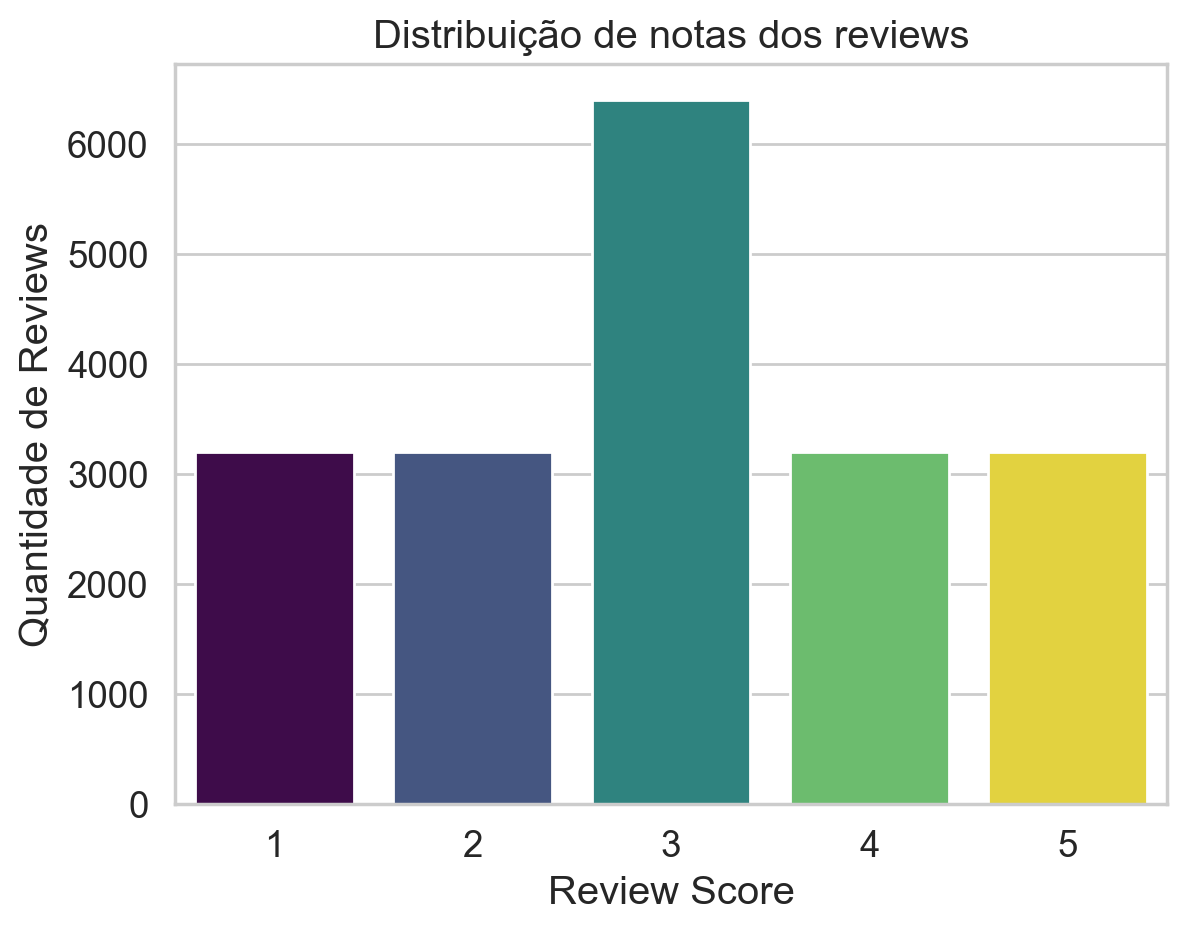

In [14]:
app_reviews_df['score'] = pd.to_numeric(app_reviews_df['score'], errors='coerce')

sns.countplot(x='score', hue='score', data=app_reviews_df, palette='viridis', legend=False)
plt.xlabel('Review Score')
plt.ylabel('Quantidade de Reviews')
plt.title('Distribuição de notas dos reviews')
plt.show()


In [15]:
def to_sentiment(rating):
    rating = int(rating)
    if rating <= 2:
        return 0
    elif rating == 3:
        return 1
    else:
        return 2

app_reviews_df['sentiment'] = app_reviews_df.score.apply(to_sentiment)

In [16]:
class_names = ['negative', 'neutral', 'positive']

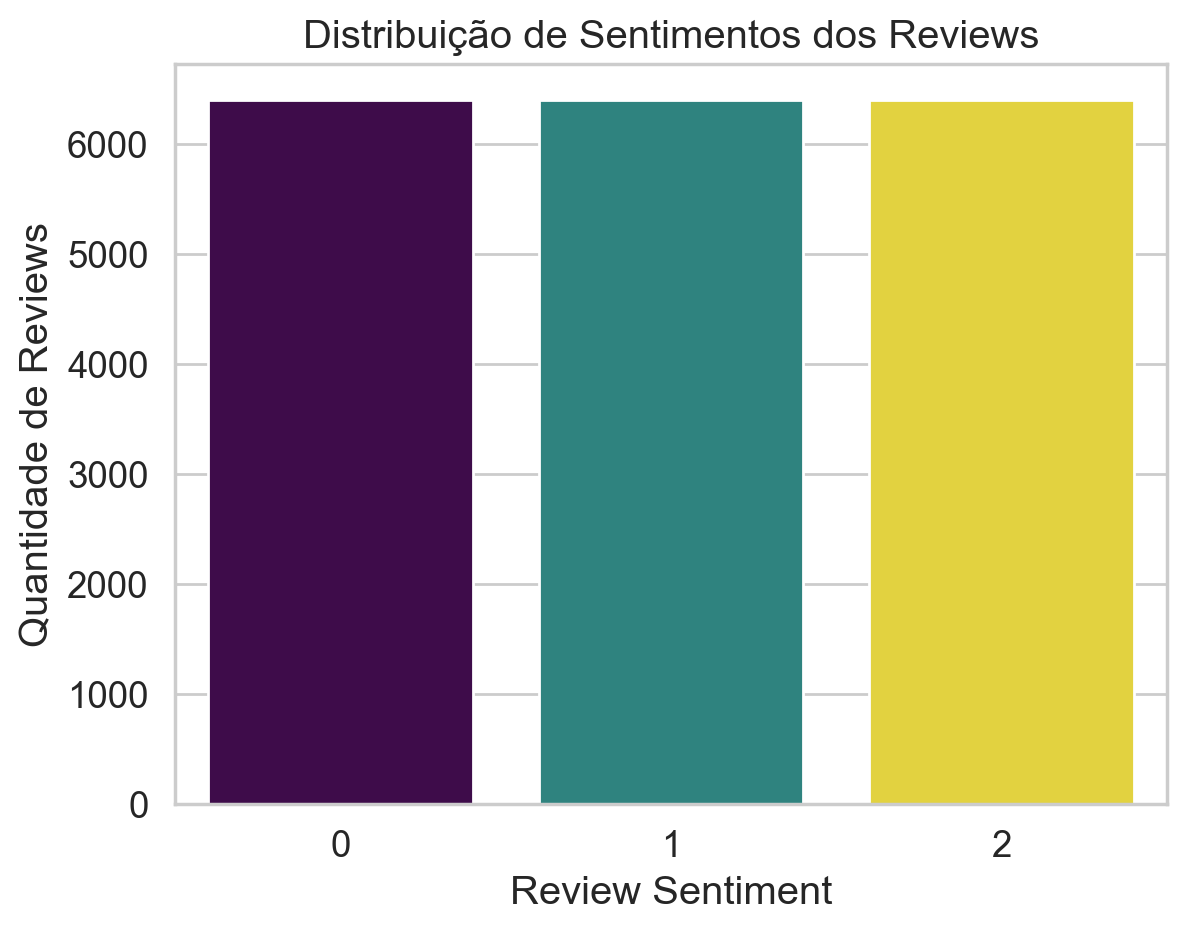

In [17]:
ax = sns.countplot(x='sentiment', data=app_reviews_df, hue='sentiment', palette='viridis', legend=False)
ax.set_xlabel('Review Sentiment')
ax.set_ylabel('Quantidade de Reviews')
plt.title('Distribuição de Sentimentos dos Reviews')
plt.show()


In [18]:
app_reviews_df.to_csv('reviews.csv', index=False, encoding='utf-8', quoting=1)